In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt

from scoreoperator.utils.trainer import TrainerModule, ScoreModel
from scoreoperator.utils.data import DataFactory
from scoreoperator.utils.configs import load_config
from scoreoperator.diffusion.bridge import DiffusionBridge
from scoreoperator.neuralop.uno import ModelFactory

In [3]:
config = load_config("butterfly_eulerian")

x0 = DataFactory.create(config.data_type, config.x0_config)
xT = DataFactory.create(config.data_type, config.xT_config)

eval_shape = (300, 2)
x0_eval = x0.eval(eval_shape)
xT_eval = xT.eval(eval_shape)

In [4]:
print(f"x0 shape: {x0_eval.shape}")
print(f"xT shape: {xT_eval.shape}")

x0 shape: (300, 2)
xT shape: (300, 2)


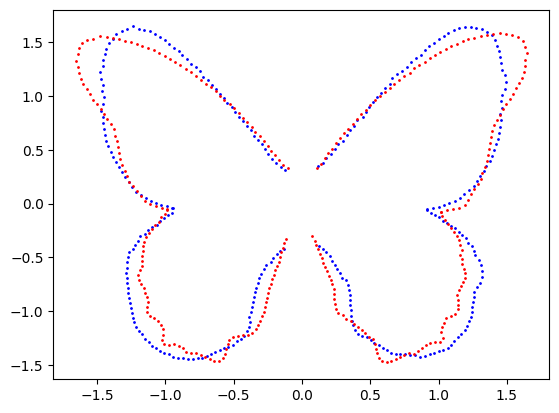

In [5]:
plt.scatter(x0_eval[:, 0], x0_eval[:, 1], s=1, c="blue", label="x0")
plt.scatter(xT_eval[:, 0], xT_eval[:, 1], s=1, c="red", label="xT")

In [7]:
config.sde_config.x0 = x0_eval
config.sde_config.xT = xT_eval
db = DiffusionBridge(
    sde_type=config.sde_type,
    sde_config=config.sde_config,
)
model = ModelFactory.create(config.model_type, config.model_config)
trainer = TrainerModule(db, model, config.train_config)
trainer.train_model(x0=None, mode="pretrained")

Number of trainable parameters: 383,186


/home/ubuntu/miniconda3/envs/scoreoperator/lib/python3.10/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from ckpts/butterfly_eulerian/checkpoint__step_None


In [9]:
score_model = ScoreModel(trainer)

xs, *_ = db.solve_forward_sde(
    x0=x0_eval,
    rng_key=jax.random.PRNGKey(config.train_config.seed),
)

ys = db.solve_reverse_bridge(
    rng_key=jax.random.PRNGKey(config.train_config.seed),
    xT=xT_eval - x0_eval,
    model=score_model,
)

xs = ys + x0_eval[None, ...]

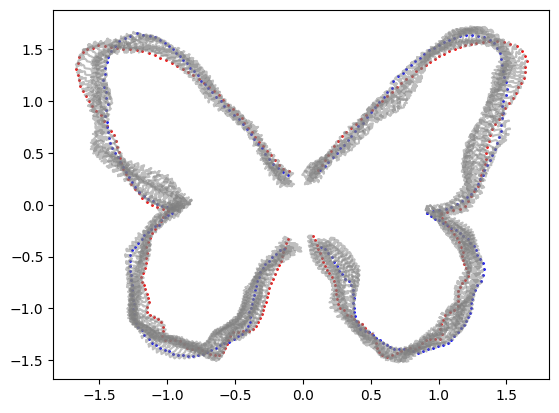

In [11]:
plt.scatter(xs[0][:, 0], xs[0][:, 1], s=1, c="red")
for i in range(xs.shape[1]):
    plt.plot(xs[:, i, 0], xs[:, i, 1], c="grey", alpha=0.5)
plt.scatter(xs[-1][:, 0], xs[-1][:, 1], s=1, c="blue")
# plt.scatter(x0_eval[:, 0], x0_eval[:, 1], s=1, c="blue", label="x0")